In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import json
from datetime import datetime, date, time, timedelta
import time as tm
from pathlib import Path

In [8]:
def timestamp_to_datetime(df, col, unit='ms'):
    df[col] = pd.to_datetime(df[col], unit=unit, utc=True).map(lambda x: x.tz_convert("America/new_York"))
    return df

def drop(df):
    df = df.drop(columns=[
        'assetMainType',
        'quoteType',
        'realtime',
        'symbol',
        'ssid',
        'reference.fsiDesc',
        'reference.description',
        'reference.otcMarketTier',
        'reference.exchangeName',
        'reference.isShortable',
        'reference.isHardToBorrow',
        'reference.cusip',
        'fundamental.fundLeverageFactor',
        'quote.lastMICId',
        'quote.bidMICId',
        'quote.askMICId',
    ])
    return df

def time_convert(df):
    timestamp_to_datetime(df,'regular.regularMarketTradeTime')
    timestamp_to_datetime(df,'extended.quoteTime')
    timestamp_to_datetime(df,'extended.tradeTime')
    timestamp_to_datetime(df,'quote.askTime')
    timestamp_to_datetime(df,'quote.bidTime')
    timestamp_to_datetime(df,'quote.quoteTime')
    timestamp_to_datetime(df,'quote.tradeTime')
    return df

def process(df):
    df = time_convert(df)
    df = drop(df)
    df = df.set_index('ident')
    return df

In [9]:
def load_day_to_xarray(date: str, data_dir="~/W_Projects/Quant_Trading/live_data") -> xr.Dataset:
    data_dir = Path(data_dir).expanduser()
    files = sorted(data_dir.glob(f"*{date}_*.parquet"))


In [17]:
data_dir="~/W_Projects/Quant_Trading/live_data"
date='2025-08-20'
data_dir = Path(data_dir).expanduser()
print(data_dir)
files = sorted(data_dir.glob(f"*{date}_*.parquet"))
print(len(files))

/home/willse/W_Projects/Quant_Trading/live_data
288


In [18]:
dfs = []
for f in files:
    df = pd.read_parquet(f)
    df = process(df)
    timestamp = f.stem.split('_')[-1]
    df['timestamp'] = pd.to_datetime(f'{date} {timestamp}')
    dfs.append(df)


In [25]:
len(dfs)

288

In [29]:
for df in dfs:
    print(f'Time: {df['timestamp'].iloc[0]} - {len(df.columns)} - {'reference.htbQuantity' in df.columns}' )

Time: 2025-08-20 00:00:00 - 61 - True
Time: 2025-08-20 00:05:00 - 61 - True
Time: 2025-08-20 00:10:00 - 61 - True
Time: 2025-08-20 00:15:00 - 61 - True
Time: 2025-08-20 00:20:00 - 61 - True
Time: 2025-08-20 00:25:00 - 61 - True
Time: 2025-08-20 00:30:00 - 61 - True
Time: 2025-08-20 00:35:00 - 61 - True
Time: 2025-08-20 00:40:00 - 61 - True
Time: 2025-08-20 00:45:00 - 61 - True
Time: 2025-08-20 00:50:00 - 61 - True
Time: 2025-08-20 00:55:00 - 61 - True
Time: 2025-08-20 01:00:00 - 61 - True
Time: 2025-08-20 01:05:00 - 61 - True
Time: 2025-08-20 01:10:00 - 61 - True
Time: 2025-08-20 01:15:00 - 61 - True
Time: 2025-08-20 01:20:00 - 61 - True
Time: 2025-08-20 01:25:00 - 61 - True
Time: 2025-08-20 01:30:00 - 61 - True
Time: 2025-08-20 01:35:00 - 61 - True
Time: 2025-08-20 01:40:00 - 61 - True
Time: 2025-08-20 01:45:00 - 61 - True
Time: 2025-08-20 01:50:00 - 61 - True
Time: 2025-08-20 01:55:00 - 61 - True
Time: 2025-08-20 02:00:00 - 61 - True
Time: 2025-08-20 02:05:00 - 61 - True
Time: 2025-0

In [20]:
big_df = pd.concat(dfs,ignore_index=False)
big_df = big_df.reset_index()
# Drop rows where ident == 'errors'
clean_df = big_df[big_df['ident'] != 'errors']

In [21]:
xr_data = clean_df.set_index(['timestamp','ident']).to_xarray()

In [22]:
xr_data

<xarray.Dataset> Size: 711MB
Dimensions:                             (timestamp: 288, ident: 5142)
Coordinates:
  * timestamp                           (timestamp) datetime64[ns] 2kB 2025-0...
  * ident                               (ident) object 41kB 'A' 'AA' ... 'ZYXI'
Data variables: (12/60)
    assetSubType                        (timestamp, ident) object 12MB 'COE' ...
    extended.askPrice                   (timestamp, ident) float64 12MB 124.2...
    extended.askSize                    (timestamp, ident) float64 12MB 108.0...
    extended.bidPrice                   (timestamp, ident) float64 12MB 115.6...
    extended.bidSize                    (timestamp, ident) float64 12MB 106.0...
    extended.lastPrice                  (timestamp, ident) float64 12MB 120.6...
    ...                                  ...
    regular.regularMarketNetChange      (timestamp, ident) float64 12MB 1.96 ...
    regular.regularMarketPercentChange  (timestamp, ident) float64 12MB 1.659...
    regular.regularMarketTradeTime      (timestamp, ident) object 12MB 2025-0...
    reference.fsiCode                   (timestamp, ident) object 12MB None ....
    invalidSymbols                      (timestamp, ident) object 12MB None ....
    reference.htbQuantity               (timestamp, ident) float64 12MB nan ....

In [15]:
import numpy as np
import pandas as pd
import xarray as xr

def sanitize_for_netcdf(ds: xr.Dataset) -> xr.Dataset:
    """
    Convert object-type variables in an xarray Dataset into NetCDF-friendly types.
    - Converts datetime-like objects into np.datetime64[ns].
    - Converts everything else into strings.
    """
    fixed = ds.copy()

    for var in fixed.variables:
        if fixed[var].dtype == "O":  # object dtype = problematic for NetCDF
            values = fixed[var].values

            # Try to detect if datetime-like
            try:
                converted = pd.to_datetime(values)
                if not pd.isnull(converted).all():  # if it actually worked
                    fixed[var] = (fixed[var].dims, converted.astype("datetime64[ns]"))
                    print(f"Converted {var} to datetime64[ns]")
                    continue
            except Exception:
                pass

            # If not datetime-like, fallback to string
            fixed[var] = (fixed[var].dims, values.astype(str))
            print(f"Converted {var} to string")

    return fixed



In [24]:
xr_clean = sanitize_for_netcdf(xr_data)
xr_clean.to_netcdf('jtest_00_out_03.nc')

Converted assetSubType to string
Converted extended.quoteTime to string
Converted extended.tradeTime to string
Converted fundamental.declarationDate to string
Converted fundamental.divExDate to string
Converted fundamental.divPayDate to string
Converted fundamental.lastEarningsDate to string
Converted fundamental.nextDivExDate to string
Converted fundamental.nextDivPayDate to string
Converted quote.askTime to string
Converted quote.bidTime to string
Converted quote.quoteTime to string
Converted quote.securityStatus to string
Converted quote.tradeTime to string
Converted reference.exchange to string
Converted regular.regularMarketTradeTime to string
Converted reference.fsiCode to string
Converted invalidSymbols to string
Converted ident to string


/tmp/ipykernel_2917/3014894294.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  converted = pd.to_datetime(values)


In [3]:
xr_new = xr.open_dataset('jtest_00_out_02.nc')

In [4]:
xr_new

<xarray.Dataset> Size: 652MB
Dimensions:                             (timestamp: 264, ident: 5144)
Coordinates:
  * ident                               (ident) object 41kB 'A' 'AA' ... 'ZYXI'
  * timestamp                           (timestamp) datetime64[ns] 2kB 2025-0...
Data variables: (12/60)
    quote.askTime                       (timestamp, ident) object 11MB ...
    quote.bidTime                       (timestamp, ident) object 11MB ...
    quote.quoteTime                     (timestamp, ident) object 11MB ...
    quote.tradeTime                     (timestamp, ident) object 11MB ...
    regular.regularMarketTradeTime      (timestamp, ident) object 11MB ...
    extended.quoteTime                  (timestamp, ident) object 11MB ...
    ...                                  ...
    reference.htbRate                   (timestamp, ident) float64 11MB ...
    regular.regularMarketLastPrice      (timestamp, ident) float64 11MB ...
    regular.regularMarketLastSize       (timestamp, ident) float64 11MB ...
    regular.regularMarketNetChange      (timestamp, ident) float64 11MB ...
    regular.regularMarketPercentChange  (timestamp, ident) float64 11MB ...
    reference.htbQuantity               (timestamp, ident) float64 11MB ...

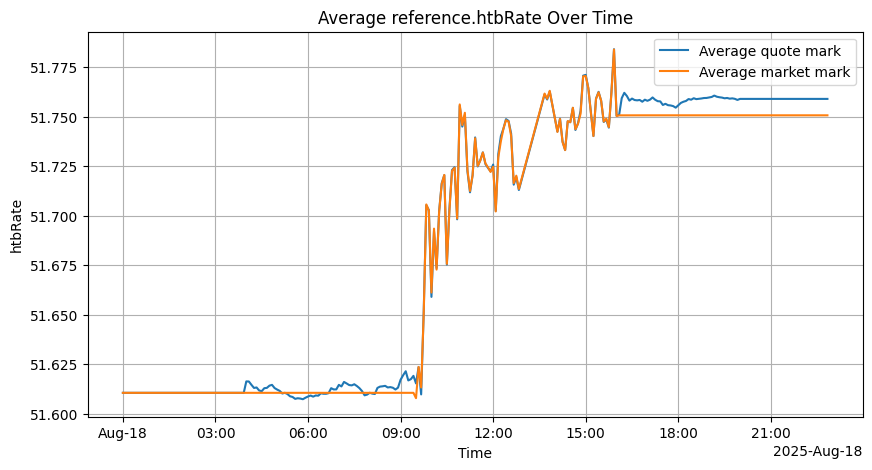

In [5]:
import matplotlib.pyplot as plt

# Compute mean across ident dimension
#avg_e_mark = (xr_new['extended.mark'].mean(dim='ident') )
avg_q_mark = xr_new['quote.mark'].mean(dim='ident')
avg_m_mark = xr_new['regular.regularMarketLastPrice'].mean(dim='ident')

# Plot over time
plt.figure(figsize=(10,5))
#avg_e_mark.plot(label='Average htbRate')
avg_q_mark.plot(label='Average quote mark')
avg_m_mark.plot(label='Average market mark')

plt.title("Average reference.htbRate Over Time")
plt.xlabel("Time")
plt.ylabel("htbRate")
plt.legend()
plt.grid(True)
plt.show()


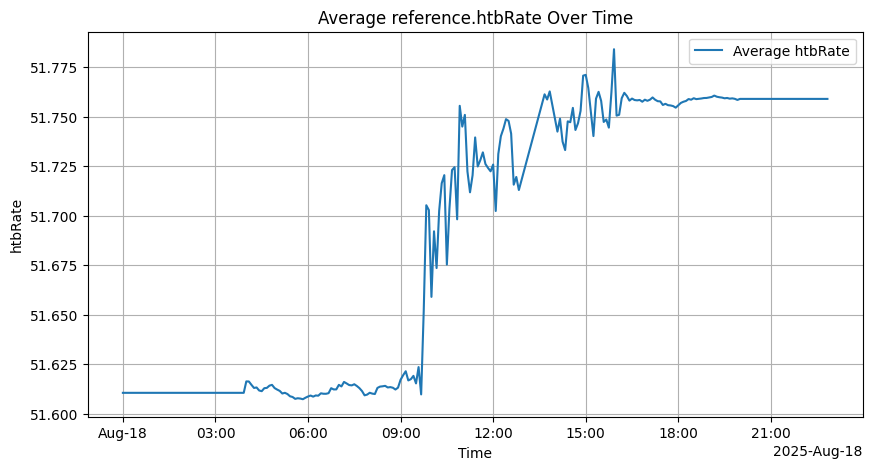

In [7]:
import matplotlib.pyplot as plt

# Compute mean across ident dimension
avg_htbRate = xr_new['quote.mark'].mean(dim='ident')

# Plot over time
plt.figure(figsize=(10,5))
avg_htbRate.plot(label='Average htbRate')

plt.title("Average reference.htbRate Over Time")
plt.xlabel("Time")
plt.ylabel("htbRate")
plt.legend()
plt.grid(True)
plt.show()
